## 그룹과제-3: ML Pipeline 구축 (모델링·앙상블)

`01_feature_engineering.ipynb`에서 만든 피처를 바탕으로 **OOF·Voting·가중 앙상블**까지 수행하는 노트북이다. 목적·데이터·평가 기준은 01과 동일하다.

In [1]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np
#!pip install category_encoders
import category_encoders as ce

# Visualization
import matplotlib.pylab as plt
from matplotlib import font_manager, rc

font_path = "C:/Windows/Fonts/NGULIM.TTF"
font = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font)
import seaborn as sns
%matplotlib inline

# Preprocessing & Feature Engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectPercentile

# Hyperparameter Optimization
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Modeling
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.base import ClassifierMixin
from sklearn.base import BaseEstimator, TransformerMixin

# Evaluation
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import log_loss

# Utility
import os
import time
import datetime
import random
import warnings; warnings.filterwarnings("ignore")
from IPython.display import Image
import pickle
from tqdm import tqdm
import platform
from itertools import combinations
from scipy.stats.mstats import gmean

#추가한것
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn import set_config
from optuna.distributions import CategoricalDistribution, IntDistribution, FloatDistribution
from optuna.integration import OptunaSearchCV, ShapleyImportanceEvaluator
import re
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from category_encoders import TargetEncoder, BinaryEncoder
import optuna
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
##코드끝나면 울리는 코드
import winsound as sd
def beepsound():
    fr = 2000    # range : 37 ~ 32767
    du = 1000     # 1000 ms ==1second
    sd.Beep(fr, du) # winsound.Beep(frequency, duration)
# !pip install bayesian-optimization
# from bayes_opt import BayesianOptimization
#!pip install num2words
# from num2words import num2words

# 1. Load data

In [2]:
X_train = pd.read_csv("../data/X_train.csv", encoding='cp949')
y_train = pd.read_csv('../data/y_train.csv', encoding='cp949').Salary  #ID, Salary

X_test = pd.read_csv("../data/X_test.csv", encoding='euc-kr')

In [3]:
X_train.info() # "직무태그,근무형태, 어학시험,대학성적" 결측치 존재

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16570 entries, 0 to 16569
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      16570 non-null  object 
 1   직종      16570 non-null  object 
 2   세부직종    16570 non-null  object 
 3   직무태그    14055 non-null  object 
 4   근무경력    16570 non-null  object 
 5   근무형태    6661 non-null   object 
 6   근무지역    16570 non-null  object 
 7   출신대학    16570 non-null  object 
 8   대학전공    16570 non-null  object 
 9   어학시험    4988 non-null   object 
 10  자격증     16570 non-null  object 
 11  대학성적    14600 non-null  float64
dtypes: float64(1), object(11)
memory usage: 1.5+ MB


In [4]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11048 entries, 0 to 11047
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      11048 non-null  object 
 1   직종      11048 non-null  object 
 2   세부직종    11048 non-null  object 
 3   직무태그    9354 non-null   object 
 4   근무경력    11048 non-null  object 
 5   근무형태    4351 non-null   object 
 6   근무지역    11048 non-null  object 
 7   출신대학    11048 non-null  object 
 8   대학전공    11048 non-null  object 
 9   어학시험    3342 non-null   object 
 10  자격증     11048 non-null  object 
 11  대학성적    9730 non-null   float64
dtypes: float64(1), object(11)
memory usage: 1.0+ MB


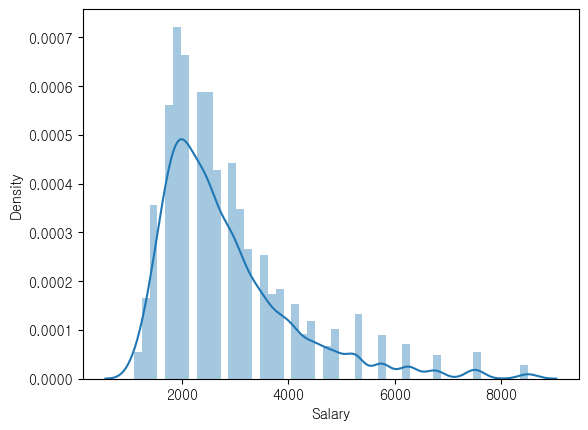

In [5]:
sns.distplot(y_train); plt.show() 

---
# 2. Preprocessing

## **1) 결측치 처리**

In [6]:
# 1.(cat) 직무태그 -> 세부직종 값으로 대체  
X_train['직무태그'] = X_train['직무태그'].fillna('없음')
X_test['직무태그'] = X_test['직무태그'].fillna('없음')

# 2.(cat) 근무형태 -> 최빈값
X_train['근무형태'] = X_train['근무형태'].fillna(X_train['근무형태'].mode()[0])                               
X_test['근무형태'] = X_test['근무형태'].fillna(X_test['근무형태'].mode()[0])      

# 3.(cat) 어학시험 -> '없음' (0이 아닌 cat형으로 바꿔야 함)
X_train['어학시험'] = X_train['어학시험'].fillna('없음')
X_test['어학시험'] = X_test['어학시험'].fillna('없음')

# 4.(num) 대학성적 -> 최빈값
X_train['대학성적'] = X_train['대학성적'].fillna(X_train['대학성적'].mode()[0]).astype(int)
X_test['대학성적'] = X_test['대학성적'].fillna(X_test['대학성적'].mode()[0]).astype(int)

display(X_train.head(), X_test.head())

,ID,직종,세부직종,직무태그,근무경력,근무형태,근무지역,출신대학,대학전공,어학시험,자격증,대학성적
0,SID100109,문화·예술·신문·방송,영상·음향·사진·카메라,"취재기자, 편집 기사, 유아 사이트 기획, 시나리오 작성",0개월,정규직,"서울,경기,서울",성균관대학교,국문,없음,無,70
1,SID100255,경영·기획·회계·사무,사무·총무·법무,없음,2년 11개월,정규직,"부산,서울,일본",신라대학교,관광경영,JLPT,無,70
2,SID100284,IT·게임,하드웨어설계·개발·관리,"하드웨어 , 무선통신 , MICOM , ASM , RF , CDMA , Firm W...",0개월,정규직,"서울,경기,",수원대학교,정보통신공,없음,有,60
3,SID100315,영업·판매·TM,기술영업,반도체,1년 0개월,정규직,"경기,서울,충북",수원대학교,정보통신,없음,有,70
4,SID100374,기술·과학·산업,기타 기술·과학·산업,기술직,0개월,정규직,"전국,전국,전국",한밭대학교,화학공학과,없음,無,70


,ID,직종,세부직종,직무태그,근무경력,근무형태,근무지역,출신대학,대학전공,어학시험,자격증,대학성적
0,SID10000,전문·교육·자격,외국어·번역·통역,"중국어,영어,강사,사무,micro office,호텔서비스",0개월,정규직,"서울,중국,캐나다",이화여자대학교,증어중문,TOEFL,無,80
1,SID100030,영업·판매·TM,해외영업,해외영업,0개월,정규직,"서울,,",중앙대학교,경영학과,,有,80
2,SID100204,건설·기계·전기·전자,기계·기계설계·기계설비,"자동차,조선품질보증,품질관리,기계,산업기계,프레스,기계설비",15년 9개월,"정규직, 해외취업","부산,경남,경북",동의대학교,산업공학과,TOEIC,有,70
3,SID100220,경영·기획·회계·사무,광고·홍보,보물을 드립니다!,0개월,정규직,"서울,경기,경기",한림대학교,"일본학과,광고'홍보학과",없음,無,70
4,SID100230,IT·게임,서버·네트워크·보안,"프로그래머, 서버,DB관리, ERP, IT 기술영업",0개월,정규직,"서울,경기,",성결대학교,컴퓨터공학,없음,有,80


## **2) Feature Engineering**

> ### **직종, 세부직종**

1. 직종별 세부직종에서 분포가 25% 이하인 값 -> '{해당 직종 이름} + 기타'로 대체
2. 직종의 고유값들을 새로운 컬럼으로 만들고, 해당 컬럼들의 값으로 해당 직종에 해당하는 행의 세부직종 값으로 매핑

=> 두 기능을 하나의 사용자 정의 함수로 구현

In [7]:
def occupation(df):
    ### 1. 25% 이하인 값을 '{해당 직종 이름} + 기타'로 대체
    for i in df['직종'].unique():
        detail = df[df['직종'] == i]['세부직종'].value_counts()
        selected_detail = detail[detail >= detail.quantile(0.25)].index.tolist()
        df.loc[(df['직종'] == i) & (~df['세부직종'].isin(selected_detail)), '세부직종'] = i + ' 기타'
    
    ### 2. '직종'의 고유값들을 가져와서 새로운 컬럼 생성
    unique_jobs = df['직종'].unique()
    for job in unique_jobs:
        df[job] = '-'  
    for i, row in df.iterrows():
        df.loc[i, row['직종']] = row['세부직종']   # 해당 직종의 세부직종 값을 해당하는 컬럼에 매핑
    
    ### 3. 세부직종_종류_개수
    df['세부직종_종류_개수'] = df['세부직종'].apply(lambda x: len(x.split('·')))

In [8]:
occupation(X_train)
occupation(X_test)

> ### **직무태그**

> ### **근무형태**

In [9]:
X_train['근무형태'] = np.where(X_train.근무형태 == "정규직", '정규직', '비정규직')
X_test['근무형태'] = np.where(X_test.근무형태 == "정규직", '정규직', '비정규직')


# 정규직: 1, 비정규직: 0으로 변환 & dtype int로 변환
X_train['근무형태'] = X_train['근무형태'].apply(lambda x: 1 if x == '정규직' else 0).astype(int)
X_test['근무형태'] = X_test['근무형태'].apply(lambda x: 1 if x == '정규직' else 0).astype(int)

> ### **근무지역**

In [10]:
# 지역 컬럼 + 해외 컬럼 만들기

def clean_location(df):
    unique_locations = df['근무지역'].str.split(',').explode().str.strip().unique()
    countries = ['일본', '인도', '미국', '해외', '캐나다', '말레이시아', '중국', '홍콩',
                    '인도네시아', '대만', '싱가포르', '방글라데시', '프랑스', '필리핀', '러시아']
    df['해외'] = 0
    for location in unique_locations:
        if location.strip() and location not in countries:  # 공백이 아니고 countries 내에 없는 경우
            df[location] = df['근무지역'].apply(lambda x: 1 if location in x else 0)
        elif location.strip():  # 공백이 아니면서 countries 내에 있는 경우
            df.loc[df['근무지역'].str.contains(location, na=False), '해외'] = 1

In [11]:
clean_location(X_train)
clean_location(X_test)

In [12]:
countries = X_train.columns[X_train.columns.get_loc('해외'):].to_list()
countries

['해외',
 '서울',
 '경기',
 '부산',
 '충북',
 '전국',
 '전북',
 '인천',
 '대전',
 '기타',
 '경남',
 '광주',
 '충남',
 '강원',
 '전남',
 '울산',
 '경북',
 '제주',
 '대구']

In [13]:
def filter_columns_by_ones_count(X_train, countries):
    # 각 피처의 1의 개수 계산
    ones_count = {feature: X_train[feature].sum() for feature in countries}

    # 1의 개수를 기준으로 내림차순 정렬
    sorted_ones_count = sorted(ones_count.items(), key=lambda x: x[1], reverse=True)

    # X_train.shape[0] * 0.05 보다 큰 1의 개수를 가진 열들을 필터링
    filtered_columns = [feature for feature, count in sorted_ones_count if count > X_train.shape[0] * 0.05]

    return filtered_columns

filtered_columns = filter_columns_by_ones_count(X_train, countries)
filtered_columns #얘네만 살려

['서울', '경기', '해외', '인천', '부산', '대전']

> ### **출신대학**

In [14]:
# 방법1. 사용자 정의 함수
def 상위10_대학(df):
    top10_list = ['연세대학교', '성균관대학교', '중앙대학교', '이화여자대학교', '서울과기대학교', '세종대학교', '성신여자대학교', '동덕여자데학교', '인천대학교', '서울여자대학교']
    df['상위10_대학'] = 0  
    for i, 대학 in enumerate(df['출신대학']):
        if 대학 in top10_list:
            df.at[i, '상위10_대학'] = 1  # 해당 행의 '상위10_대학' 값을 1로 설정


# 방법2. 사용자 정의 함수
'''
top_list=['연세대학교','성균관대학교', '중앙대학교','이화여자대학교','서울과기대학교','세종대학교','성신여자대학교','동덕여자데학교','인천대학교','서울여자대학교']
X_train['상위10_대학'] = X_train['출신대학'].apply(lambda x: 1 if x in top_list else 0)
X_test['상위10_대학'] = X_test['출신대학'].apply(lambda x: 1 if x in top_list else 0)'''

"\ntop_list=['연세대학교','성균관대학교', '중앙대학교','이화여자대학교','서울과기대학교','세종대학교','성신여자대학교','동덕여자데학교','인천대학교','서울여자대학교']\nX_train['상위10_대학'] = X_train['출신대학'].apply(lambda x: 1 if x in top_list else 0)\nX_test['상위10_대학'] = X_test['출신대학'].apply(lambda x: 1 if x in top_list else 0)"

In [15]:
상위10_대학(X_train)
상위10_대학(X_test)

>### **대학전공**

In [16]:
def major(df):
    df['대학전공'] = df['대학전공'].str.replace(r'[^a-zA-Z0-9가-힣]+|(전공|과|부)$', '', regex=True).str.lower()
    df['대학전공_대분류'] = df['대학전공'].apply(lambda x: x[:2])

In [17]:
major(X_train)
major(X_test)

> ### **어학시험**

In [18]:
X_train['어학시험'] = X_train['어학시험'].replace(' ', '없음')
X_test['어학시험'] = X_test['어학시험'].replace(' ', '없음')

> ### **자격증**

In [19]:
X_train['자격증'] = X_train['자격증'].replace({'無': 0, '有': 1})
X_test['자격증'] = X_test['자격증'].replace({'無': 0, '有': 1})

X_train['자격증'].value_counts()

0    8952
1    7618
Name: 자격증, dtype: int64

In [20]:
''' 최종 X_train & 최종 X_test '''
print(X_train.columns, len(X_train.columns))
print(X_test.columns, len(X_test.columns))

Index(['ID', '직종', '세부직종', '직무태그', '근무경력', '근무형태', '근무지역', '출신대학', '대학전공',
       '어학시험', '자격증', '대학성적', '문화·예술·신문·방송', '경영·기획·회계·사무', 'IT·게임',
       '영업·판매·TM', '기술·과학·산업', '재료·화학·섬유·의복', '전문·교육·자격', '건설·기계·전기·전자', '디자인',
       '통신·모바일', '기타 직종', '세부직종_종류_개수', '해외', '서울', '경기', '부산', '충북', '전국',
       '전북', '인천', '대전', '기타', '경남', '광주', '충남', '강원', '전남', '울산', '경북', '제주',
       '대구', '상위10_대학', '대학전공_대분류'],
      dtype='object') 45
Index(['ID', '직종', '세부직종', '직무태그', '근무경력', '근무형태', '근무지역', '출신대학', '대학전공',
       '어학시험', '자격증', '대학성적', '전문·교육·자격', '영업·판매·TM', '건설·기계·전기·전자',
       '경영·기획·회계·사무', 'IT·게임', '재료·화학·섬유·의복', '디자인', '문화·예술·신문·방송', '기타 직종',
       '기술·과학·산업', '통신·모바일', '호텔/콘도/리조트', '세부직종_종류_개수', '해외', '서울', '부산', '경남',
       '경북', '경기', '인천', '전국', '대구', '광주', '대전', '충북', '충남', '기타', '전북', '강원',
       '제주', '울산', '전남', '세종', '상위10_대학', '대학전공_대분류'],
      dtype='object') 47


---
# 3. 피처 생성

In [21]:
### '근무경력' 컬럼 수치형으로 변환
def convert_to_num(df):
    df['근무경력'] = df['근무경력'].apply(lambda x: int(x.split('년')[0])*12 + int(x.split(' ')[1].replace('개월', '')) 
                                                    if '년' in x else int(x.replace('개월', ''))                )
convert_to_num(X_train)
convert_to_num(X_test)

In [22]:
## 1. 대학성적_근무경력 -> num
X_train['대학성적_근무경력'] = X_train['대학성적'] + X_train['근무경력']
X_test['대학성적_근무경력'] = X_test['대학성적'] + X_test['근무경력']

In [23]:
## 2. 직종_근무형태
X_train['직종_근무형태'] = X_train['직종'] + '_' + X_train['근무형태'].astype(str)
X_test['직종_근무형태'] = X_test['직종'] + '_' + X_test['근무형태'].astype(str)

In [24]:
## 3. 자격증_근무형태 
X_train['자격증_근무형태'] = X_train['자격증'] + X_train['근무형태']
X_test['자격증_근무형태'] = X_test['자격증'] + X_test['근무형태']

In [25]:
## 4. 대학성적_근무형태
X_train['대학성적_근무형태'] = X_train['대학성적'] * X_train['근무형태']
X_test['대학성적_근무형태'] = X_test['대학성적'] * X_test['근무형태']

In [26]:
## 5. 출신대학_전공
X_train['출신대학_전공'] = X_train['출신대학'] + X_train['대학전공']
X_test['출신대학_전공'] = X_test['출신대학'] + X_test['대학전공']

In [27]:
## 6. 상위10대학_근무형태
X_train['상위10대학_근무형태'] = X_train['상위10_대학'] + X_train['근무형태']
X_test['상위10대학_근무형태'] = X_test['상위10_대학'] + X_test['근무형태']

In [28]:
## 7. 세부직종개수_대학성적
X_train['세부직종개수_대학성적'] = X_train['세부직종_종류_개수'] * X_train['대학성적']
X_test['세부직종개수_대학성적'] = X_test['세부직종_종류_개수'] * X_test['대학성적']

---
# 4. 수치형/범주형 피처 분리 & 학습/평가 데이터 분할

In [29]:
display(X_train.head(), X_test.head())

,ID,직종,세부직종,직무태그,근무경력,근무형태,근무지역,출신대학,대학전공,어학시험,...,대구,상위10_대학,대학전공_대분류,대학성적_근무경력,직종_근무형태,자격증_근무형태,대학성적_근무형태,출신대학_전공,상위10대학_근무형태,세부직종개수_대학성적
0,SID100109,문화·예술·신문·방송,영상·음향·사진·카메라,"취재기자, 편집 기사, 유아 사이트 기획, 시나리오 작성",0,1,"서울,경기,서울",성균관대학교,국문,없음,...,0,1,국문,70,문화·예술·신문·방송_1,1,70,성균관대학교국문,2,280
1,SID100255,경영·기획·회계·사무,사무·총무·법무,없음,35,1,"부산,서울,일본",신라대학교,관광경영,JLPT,...,0,0,관광,105,경영·기획·회계·사무_1,1,70,신라대학교관광경영,1,210
2,SID100284,IT·게임,하드웨어설계·개발·관리,"하드웨어 , 무선통신 , MICOM , ASM , RF , CDMA , Firm W...",0,1,"서울,경기,",수원대학교,정보통신공,없음,...,0,0,정보,60,IT·게임_1,2,60,수원대학교정보통신공,1,180
3,SID100315,영업·판매·TM,기술영업,반도체,12,1,"경기,서울,충북",수원대학교,정보통신,없음,...,0,0,정보,82,영업·판매·TM_1,2,70,수원대학교정보통신,1,70
4,SID100374,기술·과학·산업,기타 기술·과학·산업,기술직,0,1,"전국,전국,전국",한밭대학교,화학공학,없음,...,0,0,화학,70,기술·과학·산업_1,1,70,한밭대학교화학공학,1,210


,ID,직종,세부직종,직무태그,근무경력,근무형태,근무지역,출신대학,대학전공,어학시험,...,세종,상위10_대학,대학전공_대분류,대학성적_근무경력,직종_근무형태,자격증_근무형태,대학성적_근무형태,출신대학_전공,상위10대학_근무형태,세부직종개수_대학성적
0,SID10000,전문·교육·자격,외국어·번역·통역,"중국어,영어,강사,사무,micro office,호텔서비스",0,1,"서울,중국,캐나다",이화여자대학교,증어중문,TOEFL,...,0,1,증어,80,전문·교육·자격_1,1,80,이화여자대학교증어중문,2,240
1,SID100030,영업·판매·TM,해외영업,해외영업,0,1,"서울,,",중앙대학교,경영학,없음,...,0,1,경영,80,영업·판매·TM_1,2,80,중앙대학교경영학,2,80
2,SID100204,건설·기계·전기·전자,기계·기계설계·기계설비,"자동차,조선품질보증,품질관리,기계,산업기계,프레스,기계설비",189,0,"부산,경남,경북",동의대학교,산업공학,TOEIC,...,0,0,산업,259,건설·기계·전기·전자_0,1,0,동의대학교산업공학,0,210
3,SID100220,경영·기획·회계·사무,광고·홍보,보물을 드립니다!,0,1,"서울,경기,경기",한림대학교,일본학과광고홍보학,없음,...,0,0,일본,70,경영·기획·회계·사무_1,1,70,한림대학교일본학과광고홍보학,1,140
4,SID100230,IT·게임,서버·네트워크·보안,"프로그래머, 서버,DB관리, ERP, IT 기술영업",0,1,"서울,경기,",성결대학교,컴퓨터공학,없음,...,0,0,컴퓨,80,IT·게임_1,2,80,성결대학교컴퓨터공학,1,240


In [30]:
''' 최종 X_train & 최종 X_test '''
print(X_train.columns, len(X_train.columns))
print(X_test.columns, len(X_test.columns))

Index(['ID', '직종', '세부직종', '직무태그', '근무경력', '근무형태', '근무지역', '출신대학', '대학전공',
       '어학시험', '자격증', '대학성적', '문화·예술·신문·방송', '경영·기획·회계·사무', 'IT·게임',
       '영업·판매·TM', '기술·과학·산업', '재료·화학·섬유·의복', '전문·교육·자격', '건설·기계·전기·전자', '디자인',
       '통신·모바일', '기타 직종', '세부직종_종류_개수', '해외', '서울', '경기', '부산', '충북', '전국',
       '전북', '인천', '대전', '기타', '경남', '광주', '충남', '강원', '전남', '울산', '경북', '제주',
       '대구', '상위10_대학', '대학전공_대분류', '대학성적_근무경력', '직종_근무형태', '자격증_근무형태',
       '대학성적_근무형태', '출신대학_전공', '상위10대학_근무형태', '세부직종개수_대학성적'],
      dtype='object') 52
Index(['ID', '직종', '세부직종', '직무태그', '근무경력', '근무형태', '근무지역', '출신대학', '대학전공',
       '어학시험', '자격증', '대학성적', '전문·교육·자격', '영업·판매·TM', '건설·기계·전기·전자',
       '경영·기획·회계·사무', 'IT·게임', '재료·화학·섬유·의복', '디자인', '문화·예술·신문·방송', '기타 직종',
       '기술·과학·산업', '통신·모바일', '호텔/콘도/리조트', '세부직종_종류_개수', '해외', '서울', '부산', '경남',
       '경북', '경기', '인천', '전국', '대구', '광주', '대전', '충북', '충남', '기타', '전북', '강원',
       '제주', '울산', '전남', '세종', '상위10_대학', '대학전공_대분류', '대학성적_근무경력', '직종_근무형태',
    

In [31]:
print(X_train.info())
print(X_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16570 entries, 0 to 16569
Data columns (total 52 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           16570 non-null  object
 1   직종           16570 non-null  object
 2   세부직종         16570 non-null  object
 3   직무태그         16570 non-null  object
 4   근무경력         16570 non-null  int64 
 5   근무형태         16570 non-null  int32 
 6   근무지역         16570 non-null  object
 7   출신대학         16570 non-null  object
 8   대학전공         16570 non-null  object
 9   어학시험         16570 non-null  object
 10  자격증          16570 non-null  int64 
 11  대학성적         16570 non-null  int32 
 12  문화·예술·신문·방송  16570 non-null  object
 13  경영·기획·회계·사무  16570 non-null  object
 14  IT·게임        16570 non-null  object
 15  영업·판매·TM     16570 non-null  object
 16  기술·과학·산업     16570 non-null  object
 17  재료·화학·섬유·의복  16570 non-null  object
 18  전문·교육·자격     16570 non-null  object
 19  건설·기계·전기·전자  16570 non-nu

In [32]:
def get_value_counts(column_name):
    print(f"---------- {column_name} ----------")
    unique_values = X_train[column_name].value_counts()
    
    print(f"**고유값 개수** : {X_train[column_name].nunique()}개")
    if len(unique_values) < 10:
        print(unique_values)
        print()
    else:
        print(unique_values.head(10))
        print()

In [33]:
get_value_counts('상위10대학_근무형태')

---------- 상위10대학_근무형태 ----------
**고유값 개수** : 3개
1    10374
2     5511
0      685
Name: 상위10대학_근무형태, dtype: int64



In [34]:
col_num =['ID', '직종', '세부직종', '직무태그', '근무경력', '근무형태', '근무지역', '출신대학', '대학전공',
       '어학시험', '자격증', '대학성적', '문화·예술·신문·방송', '경영·기획·회계·사무', 'IT·게임',
       '영업·판매·TM', '기술·과학·산업', '재료·화학·섬유·의복', '전문·교육·자격', '건설·기계·전기·전자', '디자인',
       '통신·모바일', '기타 직종', '세부직종_종류_개수', '해외', '서울', '경기', '부산', '충북', '전국',
       '전북', '인천', '대전', '기타', '경남', '광주', '충남', '강원', '전남', '울산', '경북', '제주',
       '대구', '상위10_대학', '대학전공_대분류', '대학성적_근무경력', '직종_근무형태', '자격증_근무형태',
       '대학성적_근무형태', '출신대학_전공', '상위10대학_근무형태', '세부직종개수_대학성적']

len(col_num) - 14  #ID, 지역 13개

38

In [35]:
### 수치형/범주형 피처 분리 (& 학습/평가 데이터 분할)

numeric_features =     ['근무경력', '대학성적', '세부직종_종류_개수', '대학성적_근무경력', '자격증_근무형태', '세부직종개수_대학성적',
                        '대학성적_근무형태', '상위10대학_근무형태'] 

categorical_features1 = ['직종','출신대학', '어학시험', '대학전공_대분류', '직종_근무형태', '출신대학_전공', 
                        '문화·예술·신문·방송', '경영·기획·회계·사무', 'IT·게임', '영업·판매·TM', '기술·과학·산업', '재료·화학·섬유·의복', '전문·교육·자격',
                        '건설·기계·전기·전자', '디자인', '통신·모바일', '기타 직종']  #라벨
categorical_features2 = ['세부직종', '직무태그', '근무지역', '대학전공']  #캣부스트

binary_features =      ['근무형태', '자격증', '상위10_대학', '해외', '서울', '경기', '부산', '인천', '대전']  #원핫
# binary_features pca축소할 애들 뽑음

X_train = X_train[numeric_features + categorical_features1 + categorical_features2 + binary_features]   #+binary_features]  # 순서 주의!!!
X_test = X_test[numeric_features + categorical_features1 + categorical_features2 + binary_features]     #+binary_features]

X_train.shape, X_test.shape

((16570, 38), (11048, 38))

In [36]:
X_test.iloc[:, 25:29]

,세부직종,직무태그,근무지역,대학전공
0,외국어·번역·통역,"중국어,영어,강사,사무,micro office,호텔서비스","서울,중국,캐나다",증어중문
1,해외영업,해외영업,"서울,,",경영학
2,기계·기계설계·기계설비,"자동차,조선품질보증,품질관리,기계,산업기계,프레스,기계설비","부산,경남,경북",산업공학
3,광고·홍보,보물을 드립니다!,"서울,경기,경기",일본학과광고홍보학
4,서버·네트워크·보안,"프로그래머, 서버,DB관리, ERP, IT 기술영업","서울,경기,",컴퓨터공학
...,...,...,...,...
11043,제품·산업디자인,"제품,산업,팬시","서울,부산,",섬유디자인
11044,물류·유통관리,"물류,유통","경기,인천,서울",유통경영
11045,섬유·의복,없음,"서울,경기,",의류직물학
11046,영업·판매·TM 기타,판매,"부산,부산,부산",식품공학


---
# 4. 파이프라인 구축

In [37]:
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold

In [38]:
### 이상치 처리

def remove_outlier(X, q=0.05):  
    df = pd.DataFrame(X)
    return df.apply(lambda x: x.clip(x.quantile(q), x.quantile(1-q)), axis=0).values

####  **1) 파이프라인 구축**
수치형과 범주형 피처를 다르게 처리할 수 있는 ColumnTransformer를 활용

In [39]:
# numeric_features + categorical_features1 + categorical_features2 + binary_features
from category_encoders  import CatBoostEncoder
from sklearn.preprocessing import LabelEncoder
from category_encoders import BinaryEncoder
from category_encoders import CountEncoder
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("outlier", FunctionTransformer(remove_outlier, kw_args={'q':0.05})), # 함수를 전처리기로 변환하여 sklearn에 없는 새로운 전처리기를 만듬
        ("scaler", StandardScaler()), #PowerTransformer / StandardScaler
    ]
)

categorical_transformer1 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), 
        ("encoder", OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1)),
    ]
)


categorical_transformer2 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # 결측치를 해당 열의 가장 빈번한 값으로 대체
        ("encoder", CountEncoder()),  # CountEncoder를 사용한 인코딩
        ("scaler", MinMaxScaler())  # MinMaxScaler를 사용한 스케일링
    ]
)


binary_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), 
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse=True)),   
    ]
)
'''("corpus", FunctionTransformer(lambda x: x.str.replace('·',',').str.split(',').str.join(" "))),
           ("BoW", CountVectorizer()),'''  


# 피처별 각각 fit, 튜닝
column_transformer = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,       numeric_features),
        ("cat1", categorical_transformer1,  categorical_features1),
        ("cat2", categorical_transformer2, categorical_features2),
        ("bin", binary_transformer,        binary_features)         
    ]
)

##=======================================================================================================

## 전처리 파이프라인 구성
preprocessor = Pipeline(
    steps=[
        ("column", column_transformer),
        # ("selector", SelectPercentile(percentile=50)),
    ]
)


set_config(display="diagram")
preprocessor

Pipeline(steps=[('column',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('outlier',
                                                                   FunctionTransformer(func=<function remove_outlier at 0x0000024F73B6C0D0>,
                                                                                       kw_args={'q': 0.05})),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['근무경력', '대학성적', '세부직종_종류_개수',
                                                   '대학성적_근무경력', '자격증_근무형태',
                                                   '세부직종개수_대학성적', '대학성적_근무형태',
                                                   '상위10대학_근무형태']),
                                                 ('cat1',
                                                  Pipeline...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   CountEncoder(combine_min_nan_groups=True)),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['세부직종', '직무태그', '근무지역',
                                                   '대학전공']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=True))]),
                                                  ['근무형태', '자격증', '상위10_대학',
                                                   '해외', '서울', '경기', '부산', '인천',
                                                   '대전'])]))])

In [40]:
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [41]:
X_train = preprocessor.fit_transform(X_train, y_train)
X_test = preprocessor.transform(X_test)

In [42]:
X_train

array([[-0.69709319, -0.19626595,  1.80449785, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.07622361, -0.19626595,  0.67493987, ...,  0.        ,
         1.        ,  0.        ],
       [-0.69709319, -1.6358971 ,  0.67493987, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.69709319, -0.19626595,  0.67493987, ...,  1.        ,
         1.        ,  0.        ],
       [-0.69709319, -0.19626595, -0.45461812, ...,  0.        ,
         1.        ,  0.        ],
       [-0.69709319,  1.2433652 , -1.5841761 , ...,  0.        ,
         1.        ,  0.        ]])

In [43]:
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [44]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
0,-0.697093,-0.196266,1.804498,-0.724903,-0.855779,1.717163,0.183343,1.416585,6.0,18.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
1,0.076224,-0.196266,0.674940,0.039470,-0.855779,0.615940,0.183343,-0.705923,2.0,24.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,-0.697093,-1.635897,0.674940,-0.943296,1.168526,0.143988,-0.349544,-0.705923,0.0,23.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
3,-0.431956,-0.196266,-1.584176,-0.462832,1.168526,-1.586505,0.183343,-0.705923,7.0,23.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
4,-0.697093,-0.196266,0.674940,-0.724903,-0.855779,0.615940,0.183343,-0.705923,3.0,34.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16565,-0.697093,1.243365,0.674940,-0.506511,1.168526,1.087893,0.716230,-0.705923,9.0,29.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
16566,-0.697093,-0.196266,-0.454618,-0.724903,1.168526,-0.485282,0.183343,1.416585,2.0,18.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
16567,-0.697093,-0.196266,0.674940,-0.724903,1.168526,0.615940,0.183343,-0.705923,2.0,23.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
16568,-0.697093,-0.196266,-0.454618,-0.724903,-0.855779,-0.485282,0.183343,1.416585,10.0,19.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [45]:
CATBOOST_VERSION = 1.0
NFOLDS = 5
SEED = 0
Q = 0.05

In [47]:
%%time

## catboost

# 최적화된 하이퍼파라미터로 OOF를 수행하여 최종 CatBoost 모형 생성:
# No tuning => tuning한 모델에 비해 성능이 떨어지지 않음
#다실험해봐야댐 ㅇㅇ, 
#sscv = ShuffleSplit(test_size=.3334, n_splits=5, random_state=0)
models = cross_validate(CatBoostRegressor(iterations=10000,eval_metric = 'RMSE', depth = 5, 
                                          early_stopping_rounds = 1000,learning_rate = 0.1, verbose = 200),
                        X_train, y_train, 
                        cv=NFOLDS, 
                        scoring='neg_mean_squared_error', 
                        return_estimator=True)
oof_pred = np.array([m.predict(X_test) for m in models['estimator']]).mean(axis=0)

scores = models['test_score']
print("\nCatBoost CV scores: ", np.sqrt(-1*scores))
print("CatBoost CV mean = %.2f" % np.sqrt(-1*scores.mean()), "with std = %.2f" % np.sqrt(scores.std()))

0:	learn: 1212.5627588	total: 5.5ms	remaining: 55s
200:	learn: 834.6997348	total: 1.09s	remaining: 53.3s
400:	learn: 785.9829316	total: 2.2s	remaining: 52.7s
600:	learn: 751.6020346	total: 3.34s	remaining: 52.3s
800:	learn: 721.6428928	total: 4.44s	remaining: 51s
1000:	learn: 694.8077688	total: 5.58s	remaining: 50.2s
1200:	learn: 672.6858757	total: 6.69s	remaining: 49s
1400:	learn: 652.8360456	total: 7.85s	remaining: 48.2s
1600:	learn: 634.9343388	total: 9.04s	remaining: 47.4s
1800:	learn: 618.0340543	total: 10.3s	remaining: 46.8s
2000:	learn: 602.5244647	total: 11.5s	remaining: 46.1s
2200:	learn: 587.8637945	total: 12.7s	remaining: 45s
2400:	learn: 575.0590084	total: 13.9s	remaining: 44.1s
2600:	learn: 562.1721586	total: 15.2s	remaining: 43.3s
2800:	learn: 550.8299937	total: 16.4s	remaining: 42.1s
3000:	learn: 539.0812465	total: 17.6s	remaining: 41.1s
3200:	learn: 528.9019304	total: 19s	remaining: 40.3s
3400:	learn: 519.1273788	total: 20.1s	remaining: 39.1s
3600:	learn: 509.3436957	to

In [48]:
#LGBM
#LGB
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_validate
import numpy as np

models = cross_validate(LGBMRegressor(num_estimators=10000),
                        X_train, y_train,
                        cv=NFOLDS,
                        scoring='neg_mean_squared_error',
                        return_estimator=True,
                        fit_params={ "eval_metric": "rmse", "verbose": 200})

oof_pred = np.array([m.predict(X_test) for m in models['estimator']]).mean(axis=0)
("\nLightGBM CV scores: ", np.sqrt(-1 * scores))
print("LightGBM CV mean = %.2f" % np.sqrt(-1 * scores.mean()), "with std = %.2f" % np.sqrt(scores.std()))

scores = models['test_score']


[LightGBM] [Warning] Unknown parameter: num_estimators
[LightGBM] [Warning] Unknown parameter: num_estimators
[LightGBM] [Warning] Unknown parameter: num_estimators
[LightGBM] [Warning] Unknown parameter: num_estimators
[LightGBM] [Warning] Unknown parameter: num_estimators
LightGBM CV mean = 933.44 with std = 388.31


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_validate
import numpy as np

# Your data and NFOLDS definition
# ...

# Define early stopping
early_stopping_rounds = 100  # Set an appropriate value

models = cross_validate(XGBRegressor(learning_rate=0.1, max_depth=5, n_estimators=10000),
                        X_train, y_train,
                        cv=NFOLDS,
                        scoring='neg_mean_squared_error',
                        return_estimator=True,
                        fit_params={
                            "eval_metric": "rmse",
                            "early_stopping_rounds": early_stopping_rounds,
                            "eval_set": [(X_train, y_train)]  # Evaluation set
                        })

oof_pred = np.array([m.predict(X_test) for m in models['estimator']]).mean(axis=0)

scores = models['test_score']
print("\nXGBoost CV scores: ", np.sqrt(-1 * scores))
print("XGBoost CV mean = %.2f" % np.sqrt(-1 * scores.mean()), "with std = %.2f" % np.sqrt(scores.std()))


[0]	validation_0-rmse:2793.61287
[1]	validation_0-rmse:2545.12717
[2]	validation_0-rmse:2322.94691
[3]	validation_0-rmse:2126.41341
[4]	validation_0-rmse:1952.73454
[5]	validation_0-rmse:1799.95918
[6]	validation_0-rmse:1665.10154
[7]	validation_0-rmse:1547.62401
[8]	validation_0-rmse:1443.99274
[9]	validation_0-rmse:1355.41443
[10]	validation_0-rmse:1278.48239
[11]	validation_0-rmse:1212.47695
[12]	validation_0-rmse:1155.64927
[13]	validation_0-rmse:1106.76426
[14]	validation_0-rmse:1065.60470
[15]	validation_0-rmse:1031.06827
[16]	validation_0-rmse:1001.73308
[17]	validation_0-rmse:977.12108
[18]	validation_0-rmse:956.59340
[19]	validation_0-rmse:939.50508
[20]	validation_0-rmse:924.58897
[21]	validation_0-rmse:912.45685
[22]	validation_0-rmse:902.20415
[23]	validation_0-rmse:893.24190
[24]	validation_0-rmse:885.39217
[25]	validation_0-rmse:879.11276
[26]	validation_0-rmse:874.05615
[27]	validation_0-rmse:869.44268
[28]	validation_0-rmse:865.58395
[29]	validation_0-rmse:862.04425
[30

In [ ]:
#RandomForest
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# Create an imputer object with mean strategy
imputer = SimpleImputer(strategy='mean')

# Fit the imputer to X_train and transform it
X_train_imputed = imputer.fit_transform(X_train)

# Now, use RandomForestRegressor with the imputed data
random_forest = RandomForestRegressor(n_estimators=10000, max_depth=5)
models = cross_validate(random_forest,
                        X_train_imputed, y_train,
                        cv=NFOLDS,
                        scoring='neg_mean_squared_error',
                        return_estimator=True)
oof_pred = np.array([m.predict(X_test) for m in models['estimator']]).mean(axis=0)

scores = models['test_score']
print("\nRandomForest CV scores: ", np.sqrt(-1 * scores))
print("RandomForest CV mean = %.2f" % np.sqrt(-1 * scores.mean()), "with std = %.2f" % np.sqrt(scores.std()))

In [ ]:
# #DT
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.model_selection import cross_validate, ShuffleSplit
# import numpy as np

# # Your data and NFOLDS definition
# # ...

# # sscv = ShuffleSplit(test_size=0.3334, n_splits=5, random_state=0)

# # Define the DecisionTreeRegressor model with max_depth
# decision_tree = DecisionTreeRegressor(max_depth=15)  # Set max_depth here

# models = cross_validate(decision_tree,
#                         X_train, y_train,
#                         cv=NFOLDS,
#                         scoring='neg_mean_squared_error',
#                         return_estimator=True)

# oof_pred = np.array([m.predict(X_test) for m in models['estimator']]).mean(axis=0)

# scores = models['test_score']
# print("\nDecisionTreeRegressor CV scores: ", np.sqrt(-1 * scores))
# print("DecisionTreeRegressor CV mean = %.2f" % np.sqrt(-1 * scores.mean()), "with std = %.2f" % np.sqrt(scores.std()))


In [ ]:
import winsound as sd
def beepsound():
    fr = 2000    # range : 37 ~ 32767
    du = 1000     # 1000 ms ==1second
    sd.Beep(fr, du) # winsound.Beep(frequency, duration)
beepsound()

####  **2)** 파이프라인을 통한 **모형 학습** 및 **성능 확인**


In [ ]:
''' 이번 과제 핵심 포인트 '''

# 노트북 나가면 사라지니까
# 튜닝한 모델을 피클로 저장해서
# 피클을 불러오고, STACKING 하기

#최대한 파이프라인 활용하고, 모델링을 최대한 깔끔하게!

In [ ]:
# submission 화일 생성
filename = f'catboost_{CATBOOST_VERSION}_{scores.mean():.2f}.csv'
pd.DataFrame({'ID':test_id, 'Salary':oof_pred}).to_csv(filename, index=False)